# Question 14  
In this problem, you will develop a model to predict whether a given car gets high or low gas mileage based on the Auto data set.

In [2]:
from ISLP import load_data
import pandas as pd
df = load_data('Auto')
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin
name,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1
ford torino,17.0,8,302.0,140,3449,10.5,70,1
...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1


### (a)  
Create a binary variable, mpg01, that contains a 1 if mpg contains a value above its median, and a 0 if mpg contains a value below its median.  
You can compute the median using the median() method of the data frame.  
Note you may find it helpful to add a column mpg01 to the data frame by assignment.  
Assuming you have stored the data frame as Auto, this can be done as follows:  
Auto['mpg01'] = mpg01

In [3]:
df['mpg01'] = (df['mpg']>df['mpg'].median()).astype(int)
df

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
name,,,,,,,,,
chevrolet chevelle malibu,18.0,8,307.0,130,3504,12.0,70,1,0
buick skylark 320,15.0,8,350.0,165,3693,11.5,70,1,0
plymouth satellite,18.0,8,318.0,150,3436,11.0,70,1,0
amc rebel sst,16.0,8,304.0,150,3433,12.0,70,1,0
ford torino,17.0,8,302.0,140,3449,10.5,70,1,0
...,...,...,...,...,...,...,...,...,...
ford mustang gl,27.0,4,140.0,86,2790,15.6,82,1,1
vw pickup,44.0,4,97.0,52,2130,24.6,82,2,1
dodge rampage,32.0,4,135.0,84,2295,11.6,82,1,1


**Columns Description**  
`mpg`：每加侖英里數（miles per gallon），代表汽車的燃油效率。  
`cylinders`：汽缸數，表示引擎的汽缸數量。  
`displacement`：排氣量（立方英吋），指引擎氣缸能排出的總體積，通常反映引擎大小。  
`horsepower`：馬力，代表引擎輸出的動力。  
`weight`：車重（磅，pounds），表示汽車的總重量。  
`acceleration`：加速度，通常指從 0 加速到 60 英里所需的秒數。  
`year`：製造年份（通常是兩位數，例如 70 代表 1970 年）。  
`origin`：產地代碼（1 = 美國，2 = 歐洲，3 = 日本）。  
`name`：汽車名稱（品牌與型號，例如 “chevrolet chevelle malibu”）。  

### (b)  
Explore the data graphically in order to investigate the association between mpg01 and the other features.  
Which of the other features seem most likely to be useful in predicting mpg01?  
Scatterplots and boxplots may be useful tools to answer this question. Describe your findings.  

In [4]:
pd.set_option('display.float_format', '{:.2f}'.format)
df.describe()

,mpg,cylinders,displacement,horsepower,weight,acceleration,year,origin,mpg01
count,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00,392.00
mean,23.45,5.47,194.41,104.47,2977.58,15.54,75.98,1.58,0.50
std,7.81,1.71,104.64,38.49,849.40,2.76,3.68,0.81,0.50
min,9.00,3.00,68.00,46.00,1613.00,8.00,70.00,1.00,0.00
25%,17.00,4.00,105.00,75.00,2225.25,13.78,73.00,1.00,0.00
50%,22.75,4.00,151.00,93.50,2803.50,15.50,76.00,1.00,0.50
75%,29.00,8.00,275.75,126.00,3614.75,17.02,79.00,2.00,1.00
max,46.60,8.00,455.00,230.00,5140.00,24.80,82.00,3.00,1.00


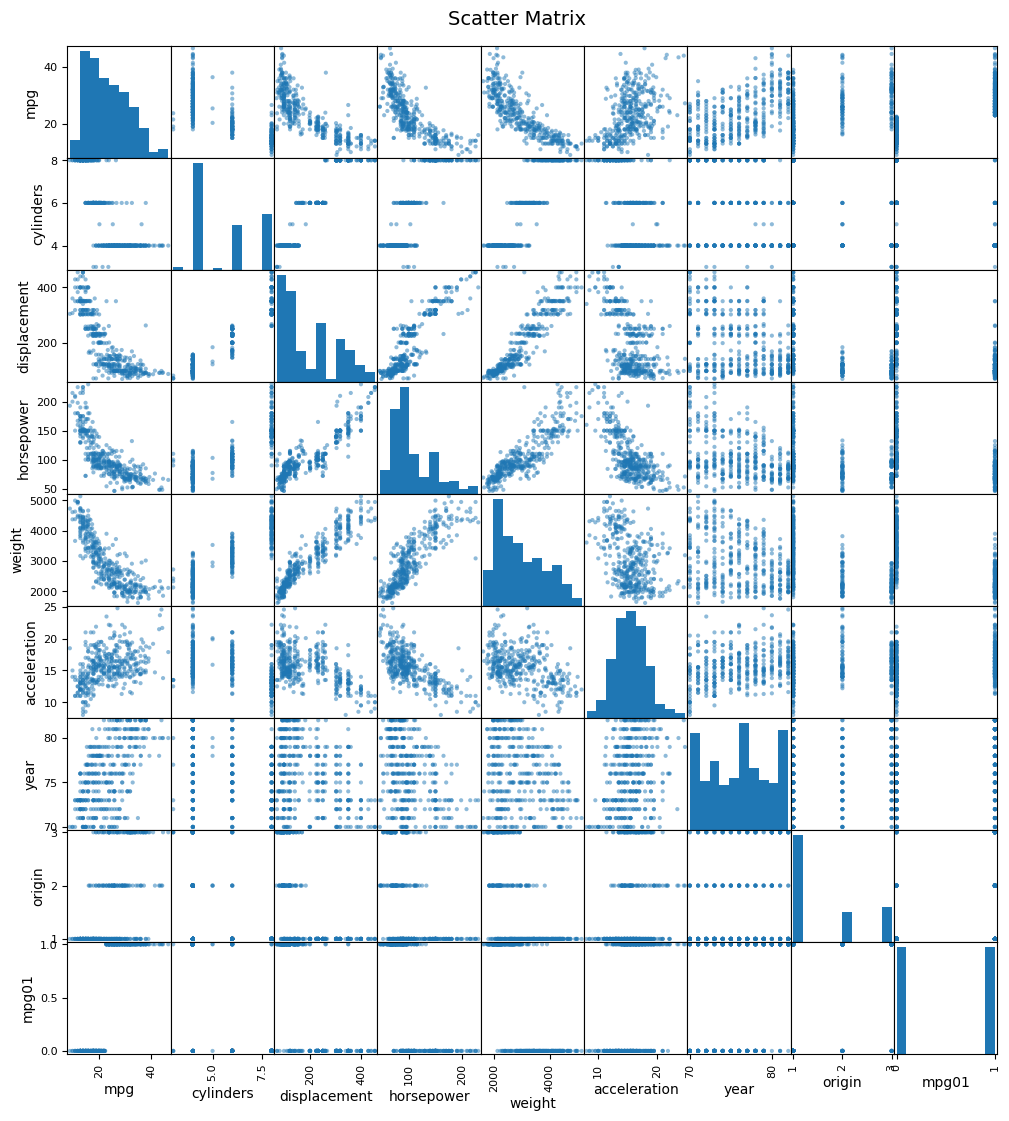

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

pd.plotting.scatter_matrix(df, figsize=(12, 12))
plt.suptitle('Scatter Matrix', fontsize=14)
#pd.plotting.scatter_matrix(data)
plt.subplots_adjust(top=0.95)
plt.show()

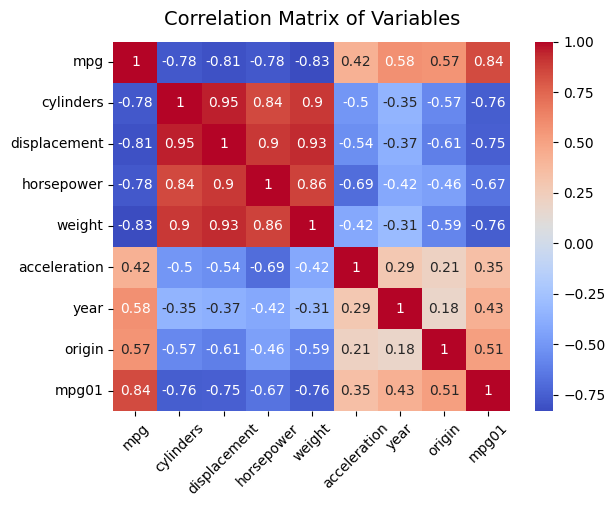

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = df.select_dtypes(include=['number']).corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Matrix of Variables', fontsize=14, pad=12)
plt.xticks(rotation=45)
plt.show()

**Notes**  
our target variable `mpg01` shows strong negative correlation to `cylinders`, `displacement`,`horsepower` ,`weight`.

### (c)  
Split the data into a training set and a test set.

In [14]:
from sklearn.model_selection import train_test_split

df_train, df_test = train_test_split(df, test_size=0.2, random_state=16)

print(df_train.shape)
print(df_test.shape)


(313, 9)
(79, 9)


### (d)  
Perform LDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?


In [15]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA

lda = LDA(store_covariance=True)

In [22]:
from ISLP.models import (ModelSpec as MS, summarize)

df1 = ['mpg', 'mpg01','year','origin']
train_cols = df_train.columns.drop(df1)

design = MS(train_cols)

X_train = design.fit_transform(df_train)
y_train = df_train.mpg01 == 1

X_test = design.transform(df_test)
y_test = df_test.mpg01 == 1

In [23]:
X_train, X_test = [M.drop(columns=['intercept'])
                   for M in [X_train, X_test]]
lda.fit(X_train, y_train)

,solver,'svd'
,shrinkage,None
,priors,None
,n_components,None
,store_covariance,True
,tol,0.0001
,covariance_estimator,None


In [24]:
from ISLP import confusion_table

lda_pred = lda.predict(X_test)
confusion_table(lda_pred, y_test)

Truth,False,True
Predicted,,
False,28,5
True,4,42


In [35]:
from sklearn.metrics import accuracy_score

test_error = 1 - accuracy_score(y_test, lda_pred)
print(f"Test Error: {test_error:.3f}")
# Test Error = 1 - Accuracy

Test Error: 0.114


### (e)  
Perform QDA on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

In [ ]:
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA

### (f)  
Perform logistic regression on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

### (g)  
Perform naive Bayes on the training data in order to predict mpg01 using the variables that seemed most associated with mpg01 in (b). What is the test error of the model obtained?

### (h)  
Perform KNN on the training data, with several values of K, in order to predict mpg01. Use only the variables that seemed most associated with mpg01 in (b). What test errors do you obtain? Which value of K seems to perform the best on this data set?